# Proyecto de Magíster: Detección de Anomalías y Posibles Fraudes en Permisos de Circulación

## Problemática
En la administración municipal, el cobro de los Permisos de Circulación Vehicular depende fuertemente de datos ingresados manualmente y tasaciones. Debido a la falta de validación estandarizada en los sistemas locales, existen múltiples errores de digitación, inconsistencias de formato y, potencialmente, **fraudes y evasiones** (por ejemplo, vehículos de alto valor comercial registrados con características alteradas para pagar menos, o modificaciones vehiculares no declaradas). Esta desestructuración de la información genera ineficiencias en la gestión pública y grandes pérdidas de ingresos municipales.

## Objetivo General
Desarrollar un pipeline de datos y un modelo de Machine Learning basado en **Aprendizaje No Supervisado (Detección de Anomalías)** para identificar patrones inusuales y registros atípicos en la base de datos de permisos de circulación, permitiendo alertar a la municipalidad sobre posibles fraudes o errores graves de tasación.

## Objetivos Específicos
1. Cargar y realizar una exploración inicial de los datos municipales (EDA).

In [11]:
# Importación de librerías iniciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización y advertencias
pd.set_option('display.max_columns', None) # Para asegurar que se vean todas las columnas al imprimir
import warnings
warnings.filterwarnings('ignore') # Limpiar la salida de advertencias rojas

print("Librerías iniciales importadas correctamente.")

Librerías iniciales importadas correctamente.


## 1. Carga de Datos y Exploración Inicial
En esta sección leemos el dataset en formato CSV, lo transformamos en un DataFrame (`df`) y visualizamos las primeras 10 filas para entender la estructura de nuestras columnas y el nivel de "suciedad" inicial de los datos.

In [12]:
# Lectura del archivo CSV y exportación a DataFrame (df)
# Asegúrate de haber subido el archivo 'permiso-circulacion-2026.csv' a tu entorno
file_path = '../datos/original/permiso-circulacion-2026.csv'

try:
    # Se agrega el parámetro encoding='utf-8' para la lectura correcta de caracteres especiales
    df = pd.read_csv(file_path, encoding='utf-8')
    print(f"Dataset cargado exitosamente. Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.\n")

    # Mostrar las primeras 10 filas (y por ende, las columnas)
    display(df.head(10))

except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{file_path}'.")
    print("Por favor, ve al panel izquierdo de Colab (ícono de carpeta) y sube el archivo CSV primero.")

Dataset cargado exitosamente. Dimensiones: 3195 filas y 21 columnas.



,_id,Fecha_Emision,Ano_Proceso,Metodo de Pago,Cuotas Permiso,Codigo_SII,Comuna_Propietario,Comuna_Permiso,Valor_Contado,Total_a_Pagar,Ano_Fabricacion,TipoVehiculo,Marca,Modelo,Cilindrada,Equipamiento,Combustible,Transmision,Tonelaje,Comuna_Anterior,Fecha_Vencimiento
0,1,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,33715,37390,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700.0,Norm,Benc,Mec,0,RIO IBAÑEZ,2026-03-31T00:00:00
1,2,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,34876,34876,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700.0,Norm,Benc,Mec,0,RIO IBAÑEZ,2027-03-31T00:00:00
2,3,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,30885,43076,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700.0,Norm,Benc,Mec,0,RIO IBAÑEZ,2024-03-31T00:00:00
3,4,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,32333,40626,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700.0,Norm,Benc,Mec,0,RIO IBAÑEZ,2025-03-31T00:00:00
4,5,2026-04-08T00:00:00,2026,PRESENCIAL,Total,NaN,COYHAIQUE,RIO IBANEZ,137846,145072,1988,CAMION,MERCEDES BENZ,L1114 48,NaN,NORM,DIES,MEC,8000,RIO BUENO,2026-09-30T00:00:00
5,6,2026-03-06T00:00:00,2026,PRESENCIAL,Total,MT139000113,RENCA,RIO IBANEZ,32333,40521,2013,Moto,LAMBRETTA,LI,150.0,NaN,Benc,Aut,0,RIO IBAÑEZ,2025-03-31T00:00:00
6,7,2026-03-06T00:00:00,2026,PRESENCIAL,Total,MT139000113,RENCA,RIO IBANEZ,33715,37283,2013,Moto,LAMBRETTA,LI,150.0,NaN,Benc,Aut,0,RIO IBAÑEZ,2026-03-31T00:00:00
7,8,2026-03-06T00:00:00,2026,PRESENCIAL,Total,MT139000113,RENCA,RIO IBANEZ,34876,34876,2013,Moto,LAMBRETTA,LI,150.0,NaN,Benc,Aut,0,RIO IBAÑEZ,2027-03-31T00:00:00
8,9,2026-03-25T00:00:00,2026,PRESENCIAL,Total,CT166004407,COYHAIQUE,RIO IBANEZ,34876,34876,2007,CAMIONETA,MITSUBISHI,L200,2500.0,Full,Dies,Mec,0,COYHAIQUE,2027-03-31T00:00:00
9,10,2026-04-14T00:00:00,2026,ONLINE,Total,MT032005815,LO BARNECHEA,RIO IBANEZ,34876,34977,2015,MOTO1,B.M.W,G,650.0,Norm,Benc,Mec,0,RIO IBAÑEZ,2027-03-31T00:00:00


In [13]:
df.shape

(3195, 21)

## 2. Limpieza de datos
En esta sección llevamos a cabo el preprocesamiento y refinamiento del DataFrame (df) para asegurar la calidad y consistencia de la información. Esto incluye el tratamiento de valores nulos o faltantes, la eliminación de registros duplicados, la corrección de tipos de datos y la estandarización de variables, garantizando así una base sólida y confiable para las siguientes etapas de análisis y modelado.



1.   Resumen de Información del DataFrame



In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3195 entries, 0 to 3194
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   _id                 3195 non-null   int64  
 1   Fecha_Emision       3195 non-null   object 
 2   Ano_Proceso         3195 non-null   int64  
 3   Metodo de Pago      3195 non-null   object 
 4   Cuotas Permiso      3195 non-null   object 
 5   Codigo_SII          2828 non-null   object 
 6   Comuna_Propietario  3195 non-null   object 
 7   Comuna_Permiso      3195 non-null   object 
 8   Valor_Contado       3195 non-null   int64  
 9   Total_a_Pagar       3195 non-null   int64  
 10  Ano_Fabricacion     3195 non-null   int64  
 11  TipoVehiculo        3195 non-null   object 
 12  Marca               3195 non-null   object 
 13  Modelo              3195 non-null   object 
 14  Cilindrada          3083 non-null   float64
 15  Equipamiento        1621 non-null   object 
 16  Combus

2.   Tipos de datos por columna



In [15]:
print(df.dtypes)

_id                     int64
Fecha_Emision          object
Ano_Proceso             int64
Metodo de Pago         object
Cuotas Permiso         object
Codigo_SII             object
Comuna_Propietario     object
Comuna_Permiso         object
Valor_Contado           int64
Total_a_Pagar           int64
Ano_Fabricacion         int64
TipoVehiculo           object
Marca                  object
Modelo                 object
Cilindrada            float64
Equipamiento           object
Combustible            object
Transmision            object
Tonelaje                int64
Comuna_Anterior        object
Fecha_Vencimiento      object
dtype: object


3.   Validacion contenido básico



In [16]:
columnas_a_validar = [
    'Metodo de Pago',
    'Cuotas Permiso',
    'TipoVehiculo',
    'Combustible',
    'Transmision'
]

print("\n--- Conteos de valores (Frecuencia) ---")
for col in columnas_a_validar:
    print(f"\nColumna: {col}")
    print(df[col].value_counts(dropna=False))
    print("-" * 30)


--- Conteos de valores (Frecuencia) ---

Columna: Metodo de Pago
Metodo de Pago
PRESENCIAL    1826
ONLINE        1369
Name: count, dtype: int64
------------------------------

Columna: Cuotas Permiso
Cuotas Permiso
Total         2077
1ra. Cuota    1096
2da. Cuota      22
Name: count, dtype: int64
------------------------------

Columna: TipoVehiculo
TipoVehiculo
CAMIONETA                  1619
STATION WAGON               965
AUTOMOVIL                   339
FURGON                       68
JEEP                         39
CAMION                       30
AMBULANCIA                   21
MOTO1                        20
MINIBUS PARTICULAR           16
Moto                         14
BUS                          12
MINIBUS TRANS  PASAJERO       9
MINIBUS                       8
SUV 2                         6
CARRO DE ARRASTRE             5
SUV                           5
Moto2                         4
BUS ESCOLAR                   2
VAN 2                         2
TAXI BASICO               



4. Genera un reporte comparando df.dtypes con df.info() y detecta inconsistencias básicas.



In [17]:
def validar_tipos_datos(df_input):

    # Obtener tipos de datos
    tipos = df_input.dtypes

    # Resumen de validación
    reporte = []
    for col, dtype in tipos.items():
        nulos = df_input[col].isnull().sum()
        porcentaje_nulos = (nulos / len(df_input)) * 100

        reporte.append({
            'Columna': col,
            'Tipo': str(dtype),
            'Nulos': nulos,
            '% Nulos': f"{porcentaje_nulos:.2f}%"
        })

    df_reporte = pd.DataFrame(reporte)
    display(df_reporte)

    # Alertas comunes
    print("\nObservaciones detectadas:")
    if 'object' in tipos.values:
        print("- Se detectaron columnas tipo 'object'. Se recomienda revisar si corresponden a strings, fechas o categorías.")

    return df_reporte

# Ejecutar la validación
reporte_validacion = validar_tipos_datos(df)

,Columna,Tipo,Nulos,% Nulos
0,_id,int64,0,0.00%
1,Fecha_Emision,object,0,0.00%
2,Ano_Proceso,int64,0,0.00%
3,Metodo de Pago,object,0,0.00%
4,Cuotas Permiso,object,0,0.00%
5,Codigo_SII,object,367,11.49%
6,Comuna_Propietario,object,0,0.00%
7,Comuna_Permiso,object,0,0.00%
8,Valor_Contado,int64,0,0.00%
9,Total_a_Pagar,int64,0,0.00%



Observaciones detectadas:
- Se detectaron columnas tipo 'object'. Se recomienda revisar si corresponden a strings, fechas o categorías.


## Valores faltantes (nulos)



1.   Filtrar solo columnas con valores nulos y ordenar de forma descendente




In [18]:
reporte_nulos = reporte_validacion[reporte_validacion['Nulos'] > 0].sort_values(by='Nulos', ascending=False)

print("--- Reporte de Columnas con Valores Nulos ---")
display(reporte_nulos)

--- Reporte de Columnas con Valores Nulos ---


,Columna,Tipo,Nulos,% Nulos
15,Equipamiento,object,1574,49.26%
5,Codigo_SII,object,367,11.49%
17,Transmision,object,122,3.82%
14,Cilindrada,float64,112,3.51%
16,Combustible,object,110,3.44%
19,Comuna_Anterior,object,12,0.38%



2.   Analisis posibles datos duplicados.



In [19]:
# 1. Calcular cantidad de duplicados totales
cantidad_duplicados = df.duplicated().sum()
print(f"Cantidad de filas totalmente duplicadas: {cantidad_duplicados}")

# 2. Si existen duplicados, mostrar los primeros ejemplos
if cantidad_duplicados > 0:
    print("\n--- Muestra de filas duplicadas (excluyendo la primera aparición) ---")
    # Mostramos las filas que se repiten, ordenadas para comparar
    display(df[df.duplicated(keep=false)].sort_values(by='_id').head(10))
else:
    print("No se encontraron filas idénticas en el dataset.")

# 3. Opcional: Revisar duplicados ignorando columnas con muchos nulos (como Equipamiento)
# Esto ayuda si hay registros que son iguales en lo importante pero varían en nulos
columnas_clave = [col for col in df.columns if col not in ['Equipamiento', 'Codigo_SII']]
duplicados_clave = df.duplicated(subset=columnas_clave).sum()
print(f"\nDuplicados considerando solo columnas clave (sin Equipamiento ni Codigo_SII): {duplicados_clave}")

Cantidad de filas totalmente duplicadas: 0
No se encontraron filas idénticas en el dataset.

Duplicados considerando solo columnas clave (sin Equipamiento ni Codigo_SII): 0



3.   Revision valores atipicos o inconsistentes.


In [20]:
# 1. Análisis estadístico de variables numéricas para detectar outliers
print("--- Estadísticas descriptivas (Variables Numéricas) ---")
display(df.describe())

--- Estadísticas descriptivas (Variables Numéricas) ---


,_id,Ano_Proceso,Valor_Contado,Total_a_Pagar,Ano_Fabricacion,Cilindrada,Tonelaje
count,3195.000000,3195.0,3.195000e+03,3.195000e+03,3195.000000,3083.000000,3195.000000
mean,1598.000000,2026.0,1.211672e+05,8.786363e+04,2016.595305,2281.597794,62.076682
std,922.461381,0.0,1.464144e+05,1.162504e+05,8.883821,752.112708,639.161391
min,1.000000,2026.0,2.311500e+04,0.000000e+00,1970.000000,100.000000,0.000000
25%,799.500000,2026.0,3.487600e+04,3.487600e+04,2011.000000,2000.000000,0.000000
50%,1598.000000,2026.0,6.969400e+04,5.082800e+04,2020.000000,2400.000000,0.000000
75%,2396.500000,2026.0,1.696820e+05,9.580900e+04,2023.000000,2500.000000,0.000000
max,3195.000000,2026.0,1.995056e+06,1.746213e+06,2026.000000,7500.000000,15000.000000


Para evitar que se vean con notación científica algunos números que estan guardados en float64 se formatea sacando los decimales.

In [21]:
pd.options.display.float_format = '{:.0f}'.format

In [22]:
display(df.describe())

,_id,Ano_Proceso,Valor_Contado,Total_a_Pagar,Ano_Fabricacion,Cilindrada,Tonelaje
count,3195,3195,3195,3195,3195,3083,3195
mean,1598,2026,121167,87864,2017,2282,62
std,922,0,146414,116250,9,752,639
min,1,2026,23115,0,1970,100,0
25%,800,2026,34876,34876,2011,2000,0
50%,1598,2026,69694,50828,2020,2400,0
75%,2396,2026,169682,95809,2023,2500,0
max,3195,2026,1995056,1746213,2026,7500,15000




4.   Buscar incosistencias en la misma columna.



In [23]:
# Columnas que deberían ser estrictamente numéricas
columnas_numericas = ['Valor_Contado', 'Total_a_Pagar', 'Ano_Fabricacion', 'Cilindrada', 'Tonelaje']

print("--- Detección de valores no numéricos (Mixed Types) ---")

for col in columnas_numericas:
    # Intentamos convertir a numérico, los errores se vuelven NaN
    temp_numeric = pd.to_numeric(df[col], errors='coerce')

    # Identificamos dónde el original NO era nulo pero la conversión SÍ falló
    # (Esto captura strings como 'NA', 'missing', o errores de tipeo)
    mascara_error = df[col].notnull() & temp_numeric.isnull()

    errores = df[mascara_error][col].unique()

    if len(errores) > 0:
        print(f"\n[!] Columna '{col}' contiene valores no numéricos detectados:")
        print(f"    Valores problemáticos: {errores}")
        print(f"    Cantidad de filas afectadas: {mascara_error.sum()}")
    else:
        print(f"\n[OK] Columna '{col}' no presenta inconsistencias de tipo (strings en números).")

--- Detección de valores no numéricos (Mixed Types) ---

[OK] Columna 'Valor_Contado' no presenta inconsistencias de tipo (strings en números).

[OK] Columna 'Total_a_Pagar' no presenta inconsistencias de tipo (strings en números).

[OK] Columna 'Ano_Fabricacion' no presenta inconsistencias de tipo (strings en números).

[OK] Columna 'Cilindrada' no presenta inconsistencias de tipo (strings en números).

[OK] Columna 'Tonelaje' no presenta inconsistencias de tipo (strings en números).


5.   Detección de estructuras anómalas.

In [24]:
# 1. Revisión de longitudes de texto excesivas en columnas clave
columnas_texto = ['TipoVehiculo', 'Marca', 'Modelo']
print("--- Análisis de Longitud de Texto (Posibles Anomalías) ---")
for col in columnas_texto:
    max_len = df[col].astype(str).map(len).max()
    print(f"Longitud máxima en {col}: {max_len} caracteres")
    # Mostrar ejemplos si superan un umbral arbitrario (ej. 50 caracteres)
    if max_len > 50:
        display(df[df[col].astype(str).map(len) > 50][[col]].head())

# 2. Validación de coherencia en fechas
# Convertimos a datetime temporalmente para la resta
fecha_emision = pd.to_datetime(df['Fecha_Emision'], errors='coerce')
fecha_vencimiento = pd.to_datetime(df['Fecha_Vencimiento'], errors='coerce')

inconsistencias_fecha = (fecha_emision > fecha_vencimiento).sum()
print(f"\nRegistros con Fecha de Emisión posterior a Vencimiento: {inconsistencias_fecha}")

# 3. Relación Cilindrada vs Tipo de Vehículo (Detección de outliers por grupo)
print("\n--- Promedio de Cilindrada por Tipo de Vehículo ---")
resumen_cilindrada = df.groupby('TipoVehiculo')['Cilindrada'].agg(['mean', 'max', 'min']).sort_values(by='mean', ascending=False)
display(resumen_cilindrada)

--- Análisis de Longitud de Texto (Posibles Anomalías) ---
Longitud máxima en TipoVehiculo: 23 caracteres
Longitud máxima en Marca: 13 caracteres
Longitud máxima en Modelo: 44 caracteres

Registros con Fecha de Emisión posterior a Vencimiento: 79

--- Promedio de Cilindrada por Tipo de Vehículo ---


,mean,max,min
TipoVehiculo,,,
CAMION,4130,7500,2600
BUS ESCOLAR,3900,3900,3900
VAN 2,3100,4000,2200
MINIBUS DE TURISMO,2800,2800,2800
MINIBUS,2661,2800,2400
CASA RODANTE,2550,2600,2500
MINIBUS TRANS PASAJERO,2538,2800,2200
CAMIONETA,2537,6700,1000
MINIBUS PARTICULAR,2484,5300,1997


6.   Filtramos los casos donde la fecha de emisión es posterior a la de vencimiento para investigar posibles patrones.

In [25]:
import pandas as pd

# Convertimos temporalmente para filtrar
fecha_emision_dt = pd.to_datetime(df['Fecha_Emision'], errors='coerce')
fecha_vencimiento_dt = pd.to_datetime(df['Fecha_Vencimiento'], errors='coerce')

# Creamos la máscara de registros erróneos
mask_fechas_erroneas = fecha_emision_dt > fecha_vencimiento_dt

# Extraemos y mostramos estos registros
df_fechas_anomalas = df[mask_fechas_erroneas].copy()

print(f"Se encontraron {len(df_fechas_anomalas)} registros con fechas inconsistentes.")

# Seleccionamos columnas relevantes para la inspección
columnas_inspeccion = ['_id', 'Fecha_Emision', 'Fecha_Vencimiento', 'Ano_Fabricacion', 'Marca', 'Modelo', 'Comuna_Propietario', 'TipoVehiculo']
display(df_fechas_anomalas[columnas_inspeccion].head(10))

Se encontraron 79 registros con fechas inconsistentes.


,_id,Fecha_Emision,Fecha_Vencimiento,Ano_Fabricacion,Marca,Modelo,Comuna_Propietario,TipoVehiculo
2,3,2026-03-20T00:00:00,2024-03-31T00:00:00,1978,PLYMOUTH,VOLARE,AISEN,AUTOMOVIL
3,4,2026-03-20T00:00:00,2025-03-31T00:00:00,1978,PLYMOUTH,VOLARE,AISEN,AUTOMOVIL
5,6,2026-03-06T00:00:00,2025-03-31T00:00:00,2013,LAMBRETTA,LI,RENCA,Moto
25,26,2026-05-13T00:00:00,2026-03-31T00:00:00,1996,MITSUBISHI,MONTERO 3.0 IE,COYHAIQUE,STATION WAGON
37,38,2026-04-23T00:00:00,2026-03-31T00:00:00,2008,DAIHATSU,TERIOS,RIO IBAÑEZ,STATION WAGON
40,41,2026-03-09T00:00:00,2025-03-31T00:00:00,2008,MITSUBISHI,MONTERO,COYHAIQUE,STATION WAGON
68,69,2026-05-26T00:00:00,2025-09-30T00:00:00,2009,JAC,HCF1042K2T,RIO IBAÑEZ,CAMION
83,84,2026-05-29T00:00:00,2026-03-31T00:00:00,2009,SUZUKI,GRAND NOMADE,RIO IBAÑEZ,STATION WAGON
93,94,2026-03-23T00:00:00,2024-03-31T00:00:00,2006,DODGE,DURANGO,RIO IBAÑEZ,STATION WAGON
94,95,2026-03-23T00:00:00,2025-03-31T00:00:00,2006,DODGE,DURANGO,RIO IBAÑEZ,STATION WAGON


Calculamos el promedio de `Ano_Fabricacion` para los 79 registros con inconsistencias de fecha.

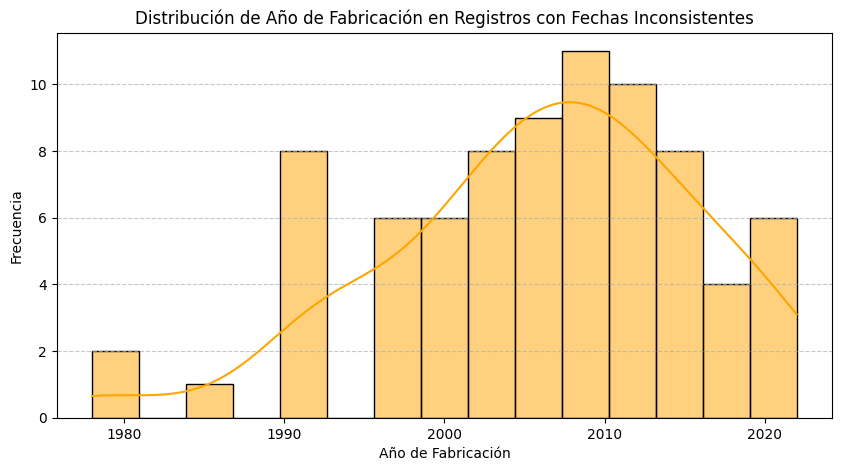

In [26]:
promedio_anio_anomalos = df_fechas_anomalas['Ano_Fabricacion'].mean()
mediana_anio_anomalos = df_fechas_anomalas['Ano_Fabricacion'].median()

# Visualizamos la distribución de los años de estos 79 registros
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df_fechas_anomalas['Ano_Fabricacion'], bins=15, kde=True, color='orange')
plt.title('Distribución de Año de Fabricación en Registros con Fechas Inconsistentes')
plt.xlabel('Año de Fabricación')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

*Visualmente podemos enteder que son casos de pago de permiso de circulación atrasados por el año de fabricación de los vehículos.*

## Limpieza básico de los datos.

In [27]:
display(reporte_nulos)

,Columna,Tipo,Nulos,% Nulos
15,Equipamiento,object,1574,49.26%
5,Codigo_SII,object,367,11.49%
17,Transmision,object,122,3.82%
14,Cilindrada,float64,112,3.51%
16,Combustible,object,110,3.44%
19,Comuna_Anterior,object,12,0.38%


Hagamos un analisis exploratorio de la columan de equipamiento

In [28]:
# 1. Análisis básico de Equipamiento
print(f"--- Análisis de la columna 'Equipamiento' ---")
total_registros = len(df)
nulos_equip = df['Equipamiento'].isnull().sum()
print(f"Total de registros: {total_registros}")
print(f"Valores nulos: {nulos_equip} ({nulos_equip/total_registros*100:.2f}%)")

# 2. Tipos de datos presentes (excluyendo nulos)
tipos_detectados = df['Equipamiento'].dropna().apply(lambda x: type(x).__name__).unique()
print(f"Tipos de datos detectados (sin nulos): {tipos_detectados}")

# 3. Valores más frecuentes y duplicados textuales
# Pasamos a mayúsculas y quitamos espacios para ver si hay 'duplicados' por formato
equip_limpio = df['Equipamiento'].dropna().astype(str).str.upper().str.strip()

print(f"\nValores únicos originales: {df['Equipamiento'].nunique()}")
print(f"Valores únicos normalizados: {equip_limpio.nunique()}")

print("\nTop 10 valores más frecuentes (normalizados):")
display(equip_limpio.value_counts().head(10))

# 4. Muestra de registros con Equipamiento
print("\nMuestra de datos no nulos en Equipamiento:")
display(df[df['Equipamiento'].notnull()][['Marca', 'Modelo', 'Equipamiento']].head(10))

--- Análisis de la columna 'Equipamiento' ---
Total de registros: 3195
Valores nulos: 1574 (49.26%)
Tipos de datos detectados (sin nulos): ['str']

Valores únicos originales: 6
Valores únicos normalizados: 3

Top 10 valores más frecuentes (normalizados):


Equipamiento
FULL    1049
NORM     374
EQUI     198
Name: count, dtype: int64


Muestra de datos no nulos en Equipamiento:


,Marca,Modelo,Equipamiento
0,PLYMOUTH,VOLARE,Norm
1,PLYMOUTH,VOLARE,Norm
2,PLYMOUTH,VOLARE,Norm
3,PLYMOUTH,VOLARE,Norm
4,MERCEDES BENZ,L1114 48,NORM
8,MITSUBISHI,L200,Full
9,B.M.W,G,Norm
10,MITSUBISHI,PAJERO JUNIOR,Full
11,MITSUBISHI,L200,Equi
12,NISSAN,V16,Full


Agregaremos el dato "EQUI" ya que tampoco no nos dice nada, no tiene ninguna defición.

In [29]:
# 1. Identificamos registros con 'EQUI' (ya detectamos que no aportan información)
mask_equi = df['Equipamiento'].astype(str).str.upper().str.strip() == 'EQUI'
casos_equi = mask_equi.sum()
nulos_originales = reporte_validacion.loc[reporte_validacion['Columna'] == 'Equipamiento', 'Nulos'].values[0]

total_no_informativos = nulos_originales + casos_equi
porcentaje_total = (total_no_informativos / len(df)) * 100

print(f"--- Resumen de Información Faltante en Equipamiento ---")
print(f"Nulos Reales: {nulos_originales}")
print(f"Valores 'EQUI': {casos_equi}")
print(f"Total de Información No Definida: {total_no_informativos} ({porcentaje_total:.2f}%)")

# 2. Definimos equip_util filtrando nulos y 'EQUI' para ver los valores útiles restantes
equip_util = df['Equipamiento'].dropna()
equip_util = equip_util[~(equip_util.astype(str).str.upper().str.strip() == 'EQUI')]

print("\nDistribución de equipamiento útil (excluyendo nulos y 'EQUI'):")
display(equip_util.value_counts())

--- Resumen de Información Faltante en Equipamiento ---
Nulos Reales: 1574
Valores 'EQUI': 198
Total de Información No Definida: 1772 (55.46%)

Distribución de equipamiento útil (excluyendo nulos y 'EQUI'):


Equipamiento
Full    883
Norm    306
FULL    166
NORM     68
Name: count, dtype: int64

Una de las primeras acciones que haremos segun las buenas practicas es eliminar la columna completa porque existen un rango mayor al 50% (55.46%) de nulos.

In [30]:
# Creamos una copia del DataFrame original para preservar los datos crudos si fuera necesario
df_clean = df.copy()

# Eliminamos la columna Equipamiento por baja representatividad (>50% nulos/sin info)
df_clean.drop(columns=['Equipamiento'], inplace=True)

print("Columna 'Equipamiento' eliminada correctamente.")
print(f"Nuevas dimensiones del dataset limpio: {df_clean.shape}")

# Verificamos que ya no esté en el listado de columnas
display(df_clean.head(5))

Columna 'Equipamiento' eliminada correctamente.
Nuevas dimensiones del dataset limpio: (3195, 20)


,_id,Fecha_Emision,Ano_Proceso,Metodo de Pago,Cuotas Permiso,Codigo_SII,Comuna_Propietario,Comuna_Permiso,Valor_Contado,Total_a_Pagar,Ano_Fabricacion,TipoVehiculo,Marca,Modelo,Cilindrada,Combustible,Transmision,Tonelaje,Comuna_Anterior,Fecha_Vencimiento
0,1,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,33715,37390,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,Benc,Mec,0,RIO IBAÑEZ,2026-03-31T00:00:00
1,2,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,34876,34876,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,Benc,Mec,0,RIO IBAÑEZ,2027-03-31T00:00:00
2,3,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,30885,43076,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,Benc,Mec,0,RIO IBAÑEZ,2024-03-31T00:00:00
3,4,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,32333,40626,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,Benc,Mec,0,RIO IBAÑEZ,2025-03-31T00:00:00
4,5,2026-04-08T00:00:00,2026,PRESENCIAL,Total,NaN,COYHAIQUE,RIO IBANEZ,137846,145072,1988,CAMION,MERCEDES BENZ,L1114 48,NaN,DIES,MEC,8000,RIO BUENO,2026-09-30T00:00:00


In [31]:
# 1. Identificamos las columnas con nulos desde el reporte previo
columnas_con_nulos = reporte_nulos['Columna'].tolist()

print(f"--- Análisis estadístico de columnas con nulos: {columnas_con_nulos} ---")

# 2. Mostramos el describe() filtrando solo esas columnas
# Nota: describe() por defecto analiza numéricas; incluimos include='all' para ver categóricas también
display(df[columnas_con_nulos].describe(include='all'))

display(reporte_nulos)

--- Análisis estadístico de columnas con nulos: ['Equipamiento', 'Codigo_SII', 'Transmision', 'Cilindrada', 'Combustible', 'Comuna_Anterior'] ---


,Equipamiento,Codigo_SII,Transmision,Cilindrada,Combustible,Comuna_Anterior
count,1621,2828,3073,3083,3085,3183
unique,6,1677,5,NaN,11,78
top,Full,CT235017723,Mec,NaN,Benc,RIO IBAÑEZ
freq,883,138,1599,NaN,1260,2411
mean,NaN,NaN,NaN,2282,NaN,NaN
std,NaN,NaN,NaN,752,NaN,NaN
min,NaN,NaN,NaN,100,NaN,NaN
25%,NaN,NaN,NaN,2000,NaN,NaN
50%,NaN,NaN,NaN,2400,NaN,NaN
75%,NaN,NaN,NaN,2500,NaN,NaN


,Columna,Tipo,Nulos,% Nulos
15,Equipamiento,object,1574,49.26%
5,Codigo_SII,object,367,11.49%
17,Transmision,object,122,3.82%
14,Cilindrada,float64,112,3.51%
16,Combustible,object,110,3.44%
19,Comuna_Anterior,object,12,0.38%


En base a ese analisis podemos imputar:

*   **Combustible y Transmisión** (3.44% y 3.82% nulos respectivamente): Vale totalmente la pena. Al ser  categóricas, podemos usar la Moda (el valor más frecuente) o, mejor aún, una imputación basada en el '**Modelo**' o '**Marca**'.
*   **Cilindrada** (3.51% nulos): Es numérica y clave para detectar fraudes de tasación. Se puede imputar usando la Mediana por '**TipoVehiculo**' o '**Modelo**' para ser más precisos.
*   **Comuna_Anterior** (<1% nulos): Es tan bajo que podemos usar un valor constante como '**SIN INFORMACION**'.

In [32]:
# 1. Imputación de categóricos (Moda condicionada por el Modelo si es posible, sino Moda global)
# Para Combustible y Transmision, usaremos la moda
df_clean['Combustible'] = df_clean['Combustible'].fillna(df_clean['Combustible'].mode()[0])
df_clean['Transmision'] = df_clean['Transmision'].fillna(df_clean['Transmision'].mode()[0])

# 2. Imputación de Cilindrada (Usamos la Mediana por Tipo de Vehículo para mayor precisión)
df_clean['Cilindrada'] = df_clean.groupby('TipoVehiculo')['Cilindrada'].transform(lambda x: x.fillna(x.median()))

# 3. Para Codigo_SII y Comuna_Anterior, usamos una etiqueta de 'DESCONOCIDO'
df_clean['Codigo_SII'] = df_clean['Codigo_SII'].fillna('SIN_CODIGO')
df_clean['Comuna_Anterior'] = df_clean['Comuna_Anterior'].fillna('OTRA')

# Validamos que ya no existan nulos en df_clean
print("--- Verificación de Nulos después de la Imputación ---")
print(df_clean.isnull().sum())

print("\nSe han imputado las columnas críticas para mantener la integridad del análisis de anomalías.")

--- Verificación de Nulos después de la Imputación ---
_id                   0
Fecha_Emision         0
Ano_Proceso           0
Metodo de Pago        0
Cuotas Permiso        0
Codigo_SII            0
Comuna_Propietario    0
Comuna_Permiso        0
Valor_Contado         0
Total_a_Pagar         0
Ano_Fabricacion       0
TipoVehiculo          0
Marca                 0
Modelo                0
Cilindrada            6
Combustible           0
Transmision           0
Tonelaje              0
Comuna_Anterior       0
Fecha_Vencimiento     0
dtype: int64

Se han imputado las columnas críticas para mantener la integridad del análisis de anomalías.


In [33]:
display(df_clean.head(5))

,_id,Fecha_Emision,Ano_Proceso,Metodo de Pago,Cuotas Permiso,Codigo_SII,Comuna_Propietario,Comuna_Permiso,Valor_Contado,Total_a_Pagar,Ano_Fabricacion,TipoVehiculo,Marca,Modelo,Cilindrada,Combustible,Transmision,Tonelaje,Comuna_Anterior,Fecha_Vencimiento
0,1,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,33715,37390,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,Benc,Mec,0,RIO IBAÑEZ,2026-03-31T00:00:00
1,2,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,34876,34876,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,Benc,Mec,0,RIO IBAÑEZ,2027-03-31T00:00:00
2,3,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,30885,43076,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,Benc,Mec,0,RIO IBAÑEZ,2024-03-31T00:00:00
3,4,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,32333,40626,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,Benc,Mec,0,RIO IBAÑEZ,2025-03-31T00:00:00
4,5,2026-04-08T00:00:00,2026,PRESENCIAL,Total,SIN_CODIGO,COYHAIQUE,RIO IBANEZ,137846,145072,1988,CAMION,MERCEDES BENZ,L1114 48,3625,DIES,MEC,8000,RIO BUENO,2026-09-30T00:00:00


Normalizacion de datos, fechas y formatos.

In [34]:
import pandas as pd
import unicodedata

def eliminar_acentos(texto):
    if not isinstance(texto, str):
        return texto
    # Normaliza a forma NFD para separar caracteres de acentos y luego filtra
    texto_normalizado = unicodedata.normalize('NFD', texto)
    return "".join([c for c in texto_normalizado if not unicodedata.combining(c)])

# 1. Normalización de Categóricos (Limpieza, Mayúsculas y Sin Acentos)
columnas_texto = ['TipoVehiculo', 'Marca', 'Modelo', 'Combustible', 'Transmision', 'Metodo de Pago', 'Comuna_Propietario', 'Comuna_Permiso']

for col in columnas_texto:
    if col in df_clean.columns:
        # Convertimos a string, quitamos espacios, pasamos a mayúsculas y eliminamos acentos
        df_clean[col] = df_clean[col].astype(str).str.strip().str.upper()
        df_clean[col] = df_clean[col].apply(eliminar_acentos)

# 2. Formateo de Fechas (Remover T00:00:00)
columnas_fecha = ['Fecha_Emision', 'Fecha_Vencimiento']
for col in columnas_fecha:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce').dt.date

# 3. Verificación de resultados
print("--- Muestra de datos normalizados (Sin acentos y estandarizados) ---")
display(df_clean[columnas_texto + columnas_fecha].head(10))

print("\n--- Verificación de Formatos de Fecha ---")
print(df_clean[columnas_fecha].dtypes)

--- Muestra de datos normalizados (Sin acentos y estandarizados) ---


,TipoVehiculo,Marca,Modelo,Combustible,Transmision,Metodo de Pago,Comuna_Propietario,Comuna_Permiso,Fecha_Emision,Fecha_Vencimiento
0,AUTOMOVIL,PLYMOUTH,VOLARE,BENC,MEC,PRESENCIAL,AISEN,RIO IBANEZ,2026-03-20,2026-03-31
1,AUTOMOVIL,PLYMOUTH,VOLARE,BENC,MEC,PRESENCIAL,AISEN,RIO IBANEZ,2026-03-20,2027-03-31
2,AUTOMOVIL,PLYMOUTH,VOLARE,BENC,MEC,PRESENCIAL,AISEN,RIO IBANEZ,2026-03-20,2024-03-31
3,AUTOMOVIL,PLYMOUTH,VOLARE,BENC,MEC,PRESENCIAL,AISEN,RIO IBANEZ,2026-03-20,2025-03-31
4,CAMION,MERCEDES BENZ,L1114 48,DIES,MEC,PRESENCIAL,COYHAIQUE,RIO IBANEZ,2026-04-08,2026-09-30
5,MOTO,LAMBRETTA,LI,BENC,AUT,PRESENCIAL,RENCA,RIO IBANEZ,2026-03-06,2025-03-31
6,MOTO,LAMBRETTA,LI,BENC,AUT,PRESENCIAL,RENCA,RIO IBANEZ,2026-03-06,2026-03-31
7,MOTO,LAMBRETTA,LI,BENC,AUT,PRESENCIAL,RENCA,RIO IBANEZ,2026-03-06,2027-03-31
8,CAMIONETA,MITSUBISHI,L200,DIES,MEC,PRESENCIAL,COYHAIQUE,RIO IBANEZ,2026-03-25,2027-03-31
9,MOTO1,B.M.W,G,BENC,MEC,ONLINE,LO BARNECHEA,RIO IBANEZ,2026-04-14,2027-03-31



--- Verificación de Formatos de Fecha ---
Fecha_Emision        object
Fecha_Vencimiento    object
dtype: object


Con esto, hemos eliminado las inconsistencias por mayúsculas/minúsculas y simplificado las fechas para que sean más legibles y útiles para el análisis de anomalías.

In [35]:
columnas_a_validar = [
    'Metodo de Pago',
    'Cuotas Permiso',
    'TipoVehiculo',
    'Combustible',
    'Transmision'
]

print("--- Conteos de valores en df_clean (Post-Limpieza y Normalización) ---")
for col in columnas_a_validar:
    if col in df_clean.columns:
        print(f"\nColumna: {col}")
        print(df_clean[col].value_counts(dropna=False))
        print("-" * 30)
    else:
        print(f"\n[!] La columna {col} no se encuentra en df_clean.")

--- Conteos de valores en df_clean (Post-Limpieza y Normalización) ---

Columna: Metodo de Pago
Metodo de Pago
PRESENCIAL    1826
ONLINE        1369
Name: count, dtype: int64
------------------------------

Columna: Cuotas Permiso
Cuotas Permiso
Total         2077
1ra. Cuota    1096
2da. Cuota      22
Name: count, dtype: int64
------------------------------

Columna: TipoVehiculo
TipoVehiculo
CAMIONETA                  1619
STATION WAGON               965
AUTOMOVIL                   339
FURGON                       68
JEEP                         39
CAMION                       30
AMBULANCIA                   21
MOTO1                        20
MINIBUS PARTICULAR           16
MOTO                         14
BUS                          12
MINIBUS TRANS  PASAJERO       9
MINIBUS                       8
SUV 2                         6
CARRO DE ARRASTRE             5
SUV                           5
MOTO2                         4
BUS ESCOLAR                   2
VAN 2                       

Ahora consolidaremos los datos

In [36]:
# Definimos el mapeo de consolidación para TipoVehiculo
mapeo_categorias = {
    'SEDAN': 'AUTOMOVIL',
    'SEDAN 2': 'AUTOMOVIL',
    'SUV': 'STATION WAGON',
    'SUV 2': 'STATION WAGON',
    'MOTO1': 'MOTO',
    'MOTO2': 'MOTO',
    'VAN 2': 'FURGON',
    'MINIBUS PARTICULAR': 'MINIBUS',
    'MINIBUS TRANS  PASAJERO': 'MINIBUS',  # Manejando el espacio doble detectado
    'MINIBUS TRANS PASAJERO': 'MINIBUS',
    'MINIBUS DE TURISMO': 'MINIBUS',
    'MINIBUS ESCOLAR': 'MINIBUS'
}

# Aplicamos el reemplazo en df_clean
df_clean['TipoVehiculo'] = df_clean['TipoVehiculo'].replace(mapeo_categorias)

# Verificamos los nuevos conteos finales
print("--- Conteos de TipoVehiculo Consolidados Finales ---")
print(df_clean['TipoVehiculo'].value_counts())

--- Conteos de TipoVehiculo Consolidados Finales ---
TipoVehiculo
CAMIONETA             1619
STATION WAGON          976
AUTOMOVIL              341
FURGON                  70
JEEP                    39
MOTO                    38
MINIBUS                 35
CAMION                  30
AMBULANCIA              21
BUS                     12
CARRO DE ARRASTRE        5
CUATRIMOTO               2
BUS ESCOLAR              2
CASA RODANTE             2
TAXI BASICO              2
MAQUINA INDUSTRIAL       1
Name: count, dtype: int64


In [37]:
# Consolidación de Combustible y Transmision
# 1. En Transmisión: CVT -> AUT
df_clean['Transmision'] = df_clean['Transmision'].replace({'CVT': 'AUT'})

# 2. En Combustible: MEC (error de registro) -> DIES
df_clean['Combustible'] = df_clean['Combustible'].replace({'MEC': 'DIES'})

# Verificación de los cambios
print("--- Conteos de Combustible (Consolidado) ---")
print(df_clean['Combustible'].value_counts())

print("\n--- Conteos de Transmision (Consolidado) ---")
print(df_clean['Transmision'].value_counts())

--- Conteos de Combustible (Consolidado) ---
Combustible
DIES    1726
BENC    1455
HIBR      10
ELEC       4
Name: count, dtype: int64

--- Conteos de Transmision (Consolidado) ---
Transmision
MEC    2315
AUT     880
Name: count, dtype: int64


Vista preliminar

In [38]:
display(df_clean.head(5))

,_id,Fecha_Emision,Ano_Proceso,Metodo de Pago,Cuotas Permiso,Codigo_SII,Comuna_Propietario,Comuna_Permiso,Valor_Contado,Total_a_Pagar,Ano_Fabricacion,TipoVehiculo,Marca,Modelo,Cilindrada,Combustible,Transmision,Tonelaje,Comuna_Anterior,Fecha_Vencimiento
0,1,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,33715,37390,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,0,RIO IBAÑEZ,2026-03-31
1,2,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,34876,34876,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,0,RIO IBAÑEZ,2027-03-31
2,3,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,30885,43076,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,0,RIO IBAÑEZ,2024-03-31
3,4,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,32333,40626,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,0,RIO IBAÑEZ,2025-03-31
4,5,2026-04-08,2026,PRESENCIAL,Total,SIN_CODIGO,COYHAIQUE,RIO IBANEZ,137846,145072,1988,CAMION,MERCEDES BENZ,L1114 48,3625,DIES,MEC,8000,RIO BUENO,2026-09-30


Vemos una cantidad enorme de datos 0 en Tonelaje, lo revisaremos.

In [39]:
cantidad_tonelaje_cero = (df_clean['Tonelaje'] == 0).sum()
porcentaje_cero = (cantidad_tonelaje_cero / len(df_clean)) * 100

print(f"--- Análisis de Tonelaje en df_clean ---")
print(f"Cantidad de registros con Tonelaje 0: {cantidad_tonelaje_cero}")
print(f"Representan el {porcentaje_cero:.2f}% del total del dataset.")

--- Análisis de Tonelaje en df_clean ---
Cantidad de registros con Tonelaje 0: 3138
Representan el 98.22% del total del dataset.


Al representar el 98.22% del total del dataset, se tomo la decision de eliminarlo de la df limpia

In [40]:
df_clean.drop(columns=['Tonelaje'], inplace=True)

print("Columna 'Tonelaje' eliminada de df_clean.")
print(f"Dimensiones finales del dataset: {df_clean.shape}")

Columna 'Tonelaje' eliminada de df_clean.
Dimensiones finales del dataset: (3195, 19)


## Vistazo final dataframe limpio

In [41]:
display(df_clean.head(5))

,_id,Fecha_Emision,Ano_Proceso,Metodo de Pago,Cuotas Permiso,Codigo_SII,Comuna_Propietario,Comuna_Permiso,Valor_Contado,Total_a_Pagar,Ano_Fabricacion,TipoVehiculo,Marca,Modelo,Cilindrada,Combustible,Transmision,Comuna_Anterior,Fecha_Vencimiento
0,1,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,33715,37390,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2026-03-31
1,2,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,34876,34876,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2027-03-31
2,3,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,30885,43076,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2024-03-31
3,4,2026-03-20,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,32333,40626,1978,AUTOMOVIL,PLYMOUTH,VOLARE,3700,BENC,MEC,RIO IBAÑEZ,2025-03-31
4,5,2026-04-08,2026,PRESENCIAL,Total,SIN_CODIGO,COYHAIQUE,RIO IBANEZ,137846,145072,1988,CAMION,MERCEDES BENZ,L1114 48,3625,DIES,MEC,RIO BUENO,2026-09-30


In [42]:
pd.options.display.float_format = '{:.0f}'.format
display(df_clean.describe())

,_id,Ano_Proceso,Valor_Contado,Total_a_Pagar,Ano_Fabricacion,Cilindrada
count,3195,3195,3195,3195,3195,3189
mean,1598,2026,121167,87864,2017,2286
std,922,0,146414,116250,9,751
min,1,2026,23115,0,1970,100
25%,800,2026,34876,34876,2011,2000
50%,1598,2026,69694,50828,2020,2400
75%,2396,2026,169682,95809,2023,2500
max,3195,2026,1995056,1746213,2026,7500


## 3. Validación Técnica y Verificación (Aseveraciones)
En esta sección implementamos comprobaciones automáticas (`assert`) para asegurar que el dataset `df_clean` cumple con los estándares de calidad antes de pasar al modelado de detección de fraudes.

In [43]:
# 1. Verificación de nulos
# Debido a que Cilindrada tiene algunos casos donde la mediana por grupo falló (grupos vacíos),
# haremos una limpieza final para asegurar que el dataset sea 100% íntegro.
df_clean['Cilindrada'] = df_clean['Cilindrada'].fillna(df_clean['Cilindrada'].median())

assert df_clean.isna().sum().sum() == 0, 'Error: Todavía existen valores nulos en el dataset'

# 2. Verificación de duplicados
assert not df_clean.duplicated().any(), 'Error: Se detectaron filas duplicadas'

# 3. Validación de rangos lógicos
# Verificamos que el año de fabricación no sea futuro y que la cilindrada sea positiva
anio_actual = 2026
assert df_clean['Ano_Fabricacion'].between(1900, anio_actual).all(), 'Error: Años de fabricación fuera de rango'
assert (df_clean['Cilindrada'] >= 0).all(), 'Error: Existen cilindradas negativas'

print("--- Todas las validaciones técnicas pasaron exitosamente ---")

# Evidencia final del estado del dataset
print("\n--- Estructura Final del Dataset (df_clean) ---")
display(df_clean.info())

print("\n--- Conteo final de nulos por columna ---")
display(df_clean.isna().sum())

--- Todas las validaciones técnicas pasaron exitosamente ---

--- Estructura Final del Dataset (df_clean) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3195 entries, 0 to 3194
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   _id                 3195 non-null   int64  
 1   Fecha_Emision       3195 non-null   object 
 2   Ano_Proceso         3195 non-null   int64  
 3   Metodo de Pago      3195 non-null   object 
 4   Cuotas Permiso      3195 non-null   object 
 5   Codigo_SII          3195 non-null   object 
 6   Comuna_Propietario  3195 non-null   object 
 7   Comuna_Permiso      3195 non-null   object 
 8   Valor_Contado       3195 non-null   int64  
 9   Total_a_Pagar       3195 non-null   int64  
 10  Ano_Fabricacion     3195 non-null   int64  
 11  TipoVehiculo        3195 non-null   object 
 12  Marca               3195 non-null   object 
 13  Modelo              3195 non-null   object 

None


--- Conteo final de nulos por columna ---


_id                   0
Fecha_Emision         0
Ano_Proceso           0
Metodo de Pago        0
Cuotas Permiso        0
Codigo_SII            0
Comuna_Propietario    0
Comuna_Permiso        0
Valor_Contado         0
Total_a_Pagar         0
Ano_Fabricacion       0
TipoVehiculo          0
Marca                 0
Modelo                0
Cilindrada            0
Combustible           0
Transmision           0
Comuna_Anterior       0
Fecha_Vencimiento     0
dtype: int64

### 4. Normalización de Nombres de Columnas (snake_case)
Para mantener la consistencia y facilitar el acceso programático, renombramos todas las columnas a minúsculas y reemplazamos espacios por guiones bajos.

In [45]:
import re

def a_snake_case(nombre):
    # Reemplaza espacios y caracteres especiales por guiones bajos
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', nombre)
    s1 = re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()
    # Limpieza adicional para espacios o puntos
    return s1.replace(' ', '_').replace('.', '').replace('__', '_').strip('_')

# Aplicar transformación
df_clean.columns = [a_snake_case(col) for col in df_clean.columns]

print("--- Columnas Normalizadas a snake_case ---")
print(df_clean.columns.tolist())

# Actualizar el archivo exportado con los nuevos nombres
df_clean.to_csv('../datos/resultado/df_clean.csv', index=False, encoding='utf-8')
print("\n Archivo df_clean.csv actualizado con nombres en snake_case.")

--- Columnas Normalizadas a snake_case ---
['id', 'fecha_emision', 'ano_proceso', 'metodo_de_pago', 'cuotas_permiso', 'codigo_sii', 'comuna_propietario', 'comuna_permiso', 'valor_contado', 'total_a_pagar', 'ano_fabricacion', 'tipo_vehiculo', 'marca', 'modelo', 'cilindrada', 'combustible', 'transmision', 'comuna_anterior', 'fecha_vencimiento']

 Archivo df_clean.csv actualizado con nombres en snake_case.


In [46]:
import os

# 1. Crear el directorio si no existe
os.makedirs('../datos/resultado', exist_ok=True)

# 2. Exportar el dataset limpio
output_path = '../datos/resultado/df_clean.csv'
df_clean.to_csv(output_path, index=False, encoding='utf-8')

print(f"Dataset exportado correctamente a: {output_path}")

# 3. Descripción final de la estructura
print("\n--- ESTRUCTURA FINAL DEL DATASET ---")
print(f"Número total de filas: {df_clean.shape[0]}")
print(f"Número total de columnas: {df_clean.shape[1]}")

print("\n--- Detalle de Columnas y Tipos de Datos ---")
print(df_clean.dtypes)

print("\n--- Resumen de Memoria ---")
display(df_clean.info())

# Pequeña verificación adicional para el reporte
print(f"\nEl archivo pesa aproximadamente: {os.path.getsize(output_path) / 1024:.2f} KB")

Dataset exportado correctamente a: ../datos/resultado/df_clean.csv

--- ESTRUCTURA FINAL DEL DATASET ---
Número total de filas: 3195
Número total de columnas: 19

--- Detalle de Columnas y Tipos de Datos ---
id                      int64
fecha_emision          object
ano_proceso             int64
metodo_de_pago         object
cuotas_permiso         object
codigo_sii             object
comuna_propietario     object
comuna_permiso         object
valor_contado           int64
total_a_pagar           int64
ano_fabricacion         int64
tipo_vehiculo          object
marca                  object
modelo                 object
cilindrada            float64
combustible            object
transmision            object
comuna_anterior        object
fecha_vencimiento      object
dtype: object

--- Resumen de Memoria ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3195 entries, 0 to 3194
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------             

None


El archivo pesa aproximadamente: 500.96 KB
